# **COLA: library for CE with joint-distribution-informed shapley towards actionable minimality**

**Library paper:** [xai-cola: A python library for sparsifying counterfactual
explanations](https://www.scholar-inbox.com/papers/Zhu2026ARXIV_xai_cola_A_Python.pdf)

**Paper:** [Refining Counterfactual Explanations With Joint-Distribution-Informed Shapley Towards Actionable Minimality](https://arxiv.org/pdf/2410.05419)  

**Github:** [github.com/understanding-ml/COLA](https://github.com/understanding-ml/COLA)

<a id='theory'></a>
## 1. **Theory**

В названии много страшных слов, но самые страшные, уверенна, `joint-distribution-informed shapley`. Информированные за счет совместного распределения Шепли — это какие? Давайте в качестве пререквизитов разберем. Но начнем с начала.

### **1.1 Зачем нужны контрфактуальные объяснения?**

Представьте систему, которая прогнозирует ваш вес через 3 года на основе признаков. Записав свои данные, вы, со стартовым весом в 60кг получаете прогноз — 80кг. Звучит невкусно и грустно и вы не довольны. Почему ваш вес должен пойти вверх, и что минимально сделать, чтобы остаться fit and amazing?


И тут вам помогло бы **контрфактуальное объяснение (CE)**. На основе того, что вам 24, вы бросаете курить и замечаете в последнее время тягу к "пожевать", минимальное изменение могло бы быть таким: *"Если вы запишите спорт как 4, а не 1 раз в неделю, то прогнозируемый вес не превысит 65кг."*

Уже понятно, что делать. Ура!

### **1.2 Как дела?**

В простейшем случае, что задача поиска контрфакта (это вот тот самый ближйший объект с другим прогнозом) может быть сформулирована как задача поиска ближайшего соседа. Эта эвристика и хороша — потому что она понятна — и плоха — ближайший сосед совершенно не точно будет с минимальными изменениями и может содержать некоторые шумы.

#### **1.2.1 Что есть?**

Среди библиотек, позволяющих реализовать Counterfactual explanations наиболее популярной является [DiCE](https://github.com/interpretml/DiCE/tree/main). В ней запрос к контрфактическому объяснению формируется как

- Во всём наборе данных (его мы тебе дадим) найди ближайшие контрфакты для выбранного экземпляра, такой что прогноз $\hat{f}(x)$ для него $\in [y_i, y_j]$`

Есть и другие алгоритмы — но в общей массе поиск контрафакта похож на вопрос выше, с вариативностями метода поиска соседа.

#### **1.2.1 Что плохо?**

- Для каждого случая может быть найдено находится несколько контрфактических объяснений, при том противоречащих друг другу (Rashomon effect).
- Найденные контрфакты не обязаны содержать минимальные изменения;

Первую проблему решить никак. И нет, я не ошиблась, формулируя это предложение :) А вот вторую можно попробовать — и разные алгоритмы как раз направлены на это. Однако, до селе не было оберток, которые позволяли бы удобно это использовать. И вот она — COLA.



### **1.3 Постановка задачи COLA и почему не в лоб**

Давайте посмотрим, почему вообще контрфакт найти не так просто. У нас есть:

**Дано:** фактические данные $\mathbf{x} \in \mathbb{R}^{n \times d}$, ML-модель $f$, желаемый результат $\mathbf{y}^*$  
**Найти:** вектор, соответствующий прогнозу $\mathbf{y}^*$, с минимальным числом изменённых признаков и максимально близкий к исходному объекту по метрике $D$:

$$\min_{\mathbf{c}, \mathbf{z}} \; D(f(\mathbf{z}), \mathbf{y}^*)$$

если убрать букву $c$ — то выше — совершенно классическая задача на поиск контрфакта с требованием (1)

- (1) $D(\mathbf{z}, \mathbf{x}) \leq \varepsilon$ — контрфактуал близок к исходному

Однако, если мы вводим ограничение на количество изменений, то у нас получаются следующие моменты. Мы минимизируем так, что:

- $\sum_{i,k} c_{ik} \leq C$ — у нас задан "бюджет" изменений. Бюджет измеряется в количестве изменений, то есть  $c_{ik} \in \{0, 1\}$ в зависимости от отсутствия или наличия изменения.
- $x_{ik}(1-c_{ik}) - Mc_{ik} \leq z_{ik} \leq x_{ik}(1-c_{ik}) + Mc_{ik}$, то есть когда изменение есть ($c_{ik} =1)$, то $z_{ik} \in [-M, M]$, для какой-то константы $M$, что даёт признаку гулять достаточно широко по множеству значений.

**Проблема: в такой постановке на нас смотрим NP-трудная задача.**

Почему? Рассмотрим простой случай $d=1$, и линейную модель, вида: $$y = \mathbf{W}\mathbf{x} + b$$

- $x \in \mathbb{R}^{n}% — вектор из $n$ примеров с одним признаком

- $\mathbf{W} \in \mathbb{R}^{m \times n}$ -матрица весов

Пусть вектор $\mathbf{x} = 0$, $D$ — евклидова метрика. Запишем задачу поиска лучшего множества контрфактов:

$$\min_{\mathbf{c}, \mathbf{z}} \; ||Wx - \mathbf{y}^*||_2^2,$$ с ограничением (1) вида: $$||x-z||_2^2 = ||z||_2^2 \leq \varepsilon$$

Так как исходный $x = 0$, и мы хотим менять наименьшее количество признаков, задача сводится к поиску вектора $z : ||z||_0 < K$, где $K$ — максимальное колиество ненулевых элементов.


То есть, вектор $z$ в нашем случае имеет $n$ координат и мы выбираем, какие из этих $n$ координат сделать ненулевыми — это классическая задача **разреженной регрессии (Sparse Regression)** или **Subset Selection** и она NP-трудная, так как:

- Нужно выбрать подмножество индексов $S \subset {1,\dots,n}, \quad |S| \le K$
- Для каждого такого подмножества решить обычную линейную регрессию на выбранных координатах.
- Выбрать лучшее решение среди всех возможных подмножеств.

Число возможных подмножеств: $\binom{n}{K}$, что растёт экспоненциально по $n$ и уже при $n=100$ и $K=10$ $\binom{100}{10} \approx 1.7 \times 10^{13}$

Не вкусно и грустно.



### **1.4 Идея COLA: p-SHAP**

Из постановки выше видно, что ключевой bottleneck здесь — в необходимости перебирать все признаки. Что если как-то заранее определить подмножество признаков поменьше? Именна эта интуиция реализуется в COLA.

#### **1.4.1 Напоминание: что такое Shapley value?**

Для функции $f(x)$ и множества признаков $N$, вклад признака $i$ определяется как:

$$\phi_i(f,x) = \sum_{S \subseteq N \setminus {i}} \frac{|S|!(|N|-|S|-1)!}{|N|!} \left[ f(x_{S \cup {i}}) - f(x_S) \right]$$

где:

* $S$ — подмножество признаков (называемое ещё коалиция, где признака $i$ нет),
* $x_S$ — вектор, где признаки вне $S$ «выключены», $x_{S \cup {i}}$ — такой же вектор, но теперь ещё и с признаком модели.
* $f(\cdot)$ — прогноз модели

#### **1.4.2 Joint-distribution Shap**

Значения Шепли считать тоже не приятно. Кроме того, локально от примера к примеру они могут различаться. Прежде всего, чтобы дать значение Шепли всей выборке, авторы вводят условные ожидания:

$$v(S) = \mathbb{E}[f(X) \mid X_S = x_S]$$

То есть значение функции коалиции $S$ — это условное ожидание модели при фиксированных признаках $S$. То есть, оно отвечает на вопрос — если признаки из $S$ фиксированы как у текущего объекта, а остальные распределены так же, как в реальных данных, чему в среднем равен прогноз модели?

Тогда Shapley значение:
$$\phi_i = \sum_{S \subseteq N \setminus {i}} \frac{|S|!(|N|-|S|-1)!}{|N|!} \Big( \mathbb{E}[f(X)\mid X_{S \cup {i}}] - \mathbb{E}[f(X)\mid X_S]\Big)$$


**Обратите внимание — оно всё ещё считается от признаков объекта, но остальные признаки берутся с таким же распределением, как распределение выборки.**


#### **1.4.3 Строим COLA**

На этом этапе мы собрали всё, чтобы понять, где оптимизация в COLA. Мы:

1. Строим любой примерный контрфакт.
1. Вычисляем Shapley values для текущего объекта.
2. Ранжируем признаки по их вкладу.
3. Меняем только топ-$p$ признаков.
4. Получаем разреженное представление.

То есть, контрфакт строится, разрешая изменения только в $p$ наиболее «влиятельных» признаках. Отсюда у нас нет перебора подмножеств — подмножество наиболее влиятельных признаков фиксировано заранее.

Пойдем тыкать библиотеку!

<a id='install'></a>
## **2. Установка и импорты**

In [1]:
# Установка библиотек
!pip install -q shap dice-ml
!pip install -q --no-deps xai-cola

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 5.4 MB/s eta 0:00:0000:0100:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 3.9 MB/s eta 0:00:00


In [4]:
!pip install cem -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 75.9 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
xai-cola 0.1.0 requires ipython>=8.0.0, but you have ipython 7.34.0 which is incompatible.
xai-cola 0.1.0 requires pandas<=2.3.0,>=2.0.0, but you have pandas 2.3.3 which is incompatible.
xai-cola 0.1.0 requires scipy<=1.16.0,>=1.13.0, but you have scipy 1.16.3 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
kaggle-environments 1.27.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 wh

In [37]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, HTML

# Sklearn
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# COLA
from xai_cola.datasets.german_credit import GermanCreditDataset
from xai_cola.ce_sparsifier.data import COLAData
from xai_cola.ce_sparsifier.models import Model
from xai_cola.ce_generator import DiCE
from xai_cola.ce_sparsifier import COLA

# Plots
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')


<a id='data'></a>
## 3. Загрузка данных и обучение модели

Чтобы использовать все возможности, используем встроенный датасет **German Credit** — классический датасет для задачи кредитного скоринга. Тогда у нас есть **задача:** предсказать кредитный риск клиента (0 = хороший, 1 = плохой).  

Стало быть, **цель CE:** найти изменения, переводящие клиента из класса 1 в 0 (получение кредита).

In [7]:
# Загрузка данных
dataset = GermanCreditDataset()
X_train, y_train, X_test, y_test = dataset.get_original_train_test_split()

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка:  {X_test.shape}")
print(f"\nРаспределение классов (train):")
print(y_train.value_counts().to_string())

print("Первые 5 примеров:")
display(X_train.head())

[INFO] Dropped rows with NaN: 478 (kept 522)
Обучающая выборка: (365, 9)
Тестовая выборка:  (157, 9)

Распределение классов (train):
Risk
0    206
1    159
Первые 5 примеров:


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
154,44,female,highly skilled,free,little,little,6419,24,car
289,67,female,highly skilled,own,little,moderate,1199,9,education
471,31,male,skilled,rent,little,little,3161,24,business
210,55,female,highly skilled,free,little,little,2578,12,furniture/equipment
494,24,male,skilled,own,little,little,2145,36,business


1. У нас стандартные признаки: возраст, пол, тип работы, тип аренды дома, состояние сберегательного и расчетного счетов, занчение кредита, срок кредита и цель.
2. Риск — это риск того, что клиент не вернет кредит. У нас несбалансированная классификация.
3. Сам класс реализован весьма необычно. Он зачем-то preprocess-ится в ините, а не встроенно, и при этом не дает взять данные с NaN-s. Оставим это на совесть библиотеки. 

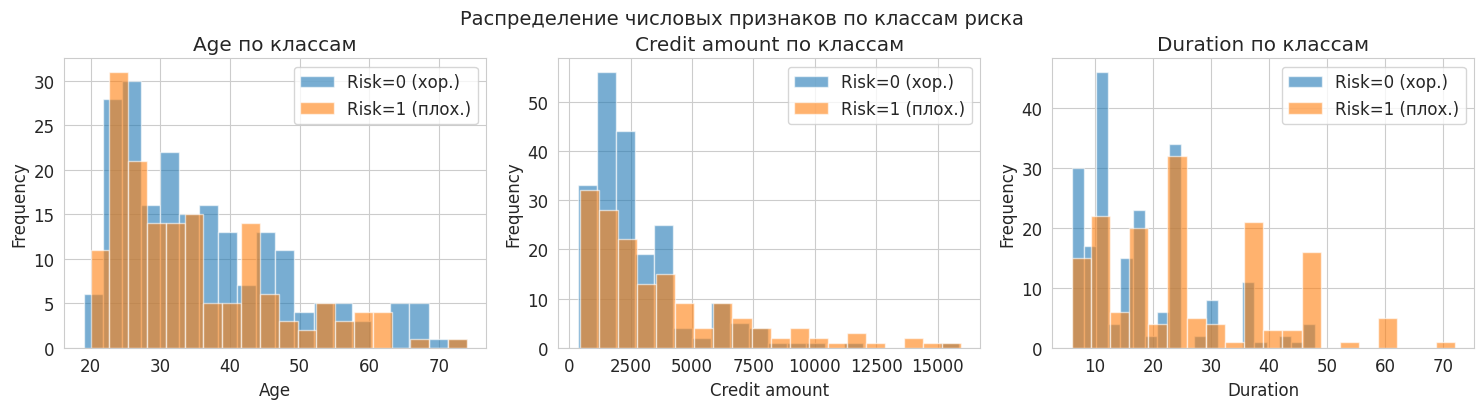

In [8]:
# Запись типов признаков + быстрый EDS
numerical_features = ['Age', 'Credit amount', 'Duration']
categorical_features = ['Sex', 'Job', 'Housing', 'Saving accounts',
                        'Checking account', 'Purpose']


# Быстрый EDA
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat in zip(axes, numerical_features):
    X_train.groupby(y_train)[feat].plot.hist(ax=ax, alpha=0.6, bins=20, legend=True)
    ax.set_title(f'{feat} по классам')
    ax.set_xlabel(feat)
    ax.legend(['Risk=0 (хор.)', 'Risk=1 (плох.)'])
plt.tight_layout()
plt.suptitle('Распределение числовых признаков по классам риска', y=1.02, fontsize=14)
plt.show()

Базово — по признакам скосов нет. Можно было бы провести стат. тесты, построить боксплоты, но для скорости — опустим это дело. 

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


# Предобработаем вместо этого категориальные признаки
for c in categorical_features:
    X_train[c] = X_train[c].astype(str)
    X_test[c] = X_test[c].astype(str)

# Сделаем стандартизацию (так как числовые признаки в разных масштабах) и ODE
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
], remainder='passthrough')


# Как модель расмотрим логистическую регрессию (простая и интерпретируемая)
lr_classifier = LogisticRegression(
    max_iter=1000, C=1.0,
    class_weight='balanced',
    random_state=42, solver='lbfgs'
)

# дерево решений тоже обучим — можете перезапустить потом pipeline дальше с ним
d_tree = RandomForestClassifier(random_state=42, max_depth=5)

# Pipeline: предобработка + классификатор
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', lr_classifier)
])

pipe_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', d_tree)
])

pipe.fit(X_train, y_train)
pipe_tree.fit(X_train, y_train)

# Оценка качества
y_pred = pipe.predict(X_test)
y_pred_tree = pipe_tree.predict(X_test)
print("Качество модели на тестовой выборке (lr model):")
print(classification_report(y_test, y_pred, target_names=['Risk=0 (хор.)', 'Risk=1 (плох.)']))

print("Качество модели на тестовой выборке (tree model):")
print(classification_report(y_test, y_pred_tree, target_names=['Risk=0 (хор.)', 'Risk=1 (плох.)']))

Качество модели на тестовой выборке (lr model):
                precision    recall  f1-score   support

 Risk=0 (хор.)       0.63      0.67      0.65        85
Risk=1 (плох.)       0.58      0.53      0.55        72

      accuracy                           0.61       157
     macro avg       0.60      0.60      0.60       157
  weighted avg       0.60      0.61      0.60       157

Качество модели на тестовой выборке (tree model):
                precision    recall  f1-score   support

 Risk=0 (хор.)       0.58      0.75      0.66        85
Risk=1 (плох.)       0.55      0.36      0.44        72

      accuracy                           0.57       157
     macro avg       0.57      0.56      0.55       157
  weighted avg       0.57      0.57      0.56       157



<a id='dice'></a>
## 4. Чистый DiCE без COLA (baseline)

**DiCE** (Diverse Counterfactual Explanations) — популярный instance-wise CE алгоритм.  
Он генерирует набор контрфактуалов, которые меняют предсказание модели, но может менять **много лишних признаков**.

In [10]:
# Подготовка данных в формате COLA
# Берём клиентов с плохим риском (Risk=1) — хотим их перевести в Risk=0
df_full = pd.concat([X_train, y_train], axis=1)
df_risk_1 = df_full[df_full['Risk'] == 1].sample(8, random_state=42)

print(f"Выбрано {len(df_risk_1)} клиентов с плохим кредитным риском (Risk=1)")
print("\nПрофили клиентов:")
display(df_risk_1[numerical_features + categorical_features[:3]].head(4))

Выбрано 8 клиентов с плохим кредитным риском (Risk=1)

Профили клиентов:


,Age,Credit amount,Duration,Sex,Job,Housing
407,31,3108,30,male,unskilled and resident,own
96,33,950,15,male,skilled,rent
378,27,14027,60,male,highly skilled,own
479,46,697,12,male,skilled,own


In [ ]:
# Инициализация интерфейса данных COLA
data = COLAData(
    factual_data=df_risk_1,
    label_column='Risk',
    numerical_features=numerical_features
)

# Инициализация интерфейса модели COLA
ml_model = Model(model=pipe, backend="sklearn")

# Генерация контрфактуалов через DiCE
explainer = DiCE(ml_model=ml_model)

factual, counterfactual = explainer.generate_counterfactuals(
    data=data,
    factual_class=1,           # класс, ИЗ которого переводим
    total_cfs=2,               # 2 контрфактуала на каждый пример
    features_to_keep=['Age', 'Sex'],   # нельзя менять эти признаки
    continuous_features=numerical_features
)

print(f"Фактических примеров: {factual.shape[0]}")
print(f"Контрфактуальных примеров: {counterfactual.shape[0]}")

Генерация контрфактуалов через DiCE...


100%|██████████| 8/8 [00:00<00:00,  8.84it/s]

Контрфактуалы сгенерированы!
Фактических примеров: 8
Контрфактуальных примеров: 16


Посмотрим на фактические и контрфактуальные примеры. 

In [14]:
factual

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
407,31,male,unskilled and resident,own,little,little,3108,30,furniture/equipment,1
96,33,male,skilled,rent,little,little,950,15,car,1
378,27,male,highly skilled,own,little,moderate,14027,60,car,1
479,46,male,skilled,own,little,little,697,12,car,1
178,44,male,highly skilled,rent,little,little,3384,6,furniture/equipment,1
24,37,male,skilled,own,little,rich,2100,18,radio/TV,1
245,26,female,skilled,rent,little,little,3114,18,furniture/equipment,1
271,24,female,skilled,own,little,little,3190,18,radio/TV,1


In [13]:
counterfactual

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,31,male,unskilled and resident,own,little,rich,3108,22,furniture/equipment,0
1,31,male,unskilled and resident,own,little,little,3108,7,furniture/equipment,0
2,33,male,skilled,rent,little,little,950,8,car,0
3,33,male,skilled,rent,little,little,3783,15,furniture/equipment,0
4,27,male,highly skilled,own,little,moderate,14027,14,car,0
5,27,male,highly skilled,own,little,moderate,14027,22,car,0
6,46,male,highly skilled,own,little,little,12784,12,car,0
7,46,male,skilled,own,little,little,11472,12,car,0
8,44,male,highly skilled,rent,little,little,12597,6,furniture/equipment,0
9,44,male,highly skilled,rent,little,little,10234,6,furniture/equipment,0


Заметим, что:
1. Возраст в основном оказался нетронутым признаком, как и пол, saving accounts и checking account.
2. Примеры немного неудобно расположены (было бы здорово, например, сохранить индексы оригиналов), но интуитивно понятно, что идут они друг за другом, то есть для первого примера, его контр-примеры — 1, 2, для второго — 3, 4 и так далее.
3. Credit amount и duration меняются достаточно сильно, чаще чем цель кредита. 

In [15]:
# Добавим контрфактуалы в объект данных, чтобы с ними еще поработать. 
data.add_counterfactuals(counterfactual, with_target_column=True)
data.summary()

{'factual_samples': 8,
 'feature_count': 9,
 'label_column': 'Risk',
 'all_columns': ['Age',
  'Sex',
  'Job',
  'Housing',
  'Saving accounts',
  'Checking account',
  'Credit amount',
  'Duration',
  'Purpose',
  'Risk'],
 'has_counterfactual': True,
 'has_transform_method': False,
 'has_transformed_data': False,
 'counterfactual_samples': 16}

In [ ]:
# Посмотрим сколько признаков меняет DiCE?
def count_changes(factual_df, counterfactual_df, feature_cols):
    """Считаем количество изменённых признаков для каждого примера"""
    changes = []
    for i in range(len(factual_df)):
        changed = sum(
            str(factual_df.iloc[i][col]) != str(counterfactual_df.iloc[i][col])
            for col in feature_cols
        )
        changes.append(changed)
    return np.array(changes)

feature_cols = numerical_features + categorical_features
# Берём первый контрфактуал для каждого примера
cf_first = counterfactual.iloc[::2, :]
# Берём второая контрфактуал для каждого примера
cf_second = counterfactual.iloc[1::2, :]

# считаем кол-во признаков
changes_first = count_changes(factual, cf_first, feature_cols)
changes_second = count_changes(factual, cf_second, feature_cols)

mean_per_example = (changes_first + changes_second)/2

print(f"   Всего признаков: {len(feature_cols)}")
print(f"   Среднее изменений на пример: ~{np.mean(mean_per_example)}")

   Всего признаков: 9
   Среднее изменений на пример: ~1.5


Не так много. Посмотрим, можно ли меньше. 

<a id='cola'></a>
## 5. Применение COLA для разреживания

COLA принимает контрфактуалы DiCE и **разреживает** их — оставляет только самые важные изменения.

In [39]:
# Инициализация COLA
from xai_cola.ce_sparsifier import COLA
sparsifier = COLA(
    data=data,
    ml_model=ml_model
)

# Выбор стратегии
sparsifier.set_policy(
    matcher="ot",         # Оптимальный транспорт для сопоставления
    attributor="pshap",   # p-SHAP для атрибуции признаков
    random_state=42
)


Policy set: pshap with Optimal Transport Matching.


In [41]:
# Найдем минимальное количество изменений
limited_actions = sparsifier.query_minimum_actions()

print(f'Limited actions count: {limited_actions}')

refined_cf_df = sparsifier.get_refined_counterfactual(limited_actions=limited_actions)
display(refined_cf_df)

The minimum number of actions is 10
Limited actions count: 10


  0%|          | 0/1 [00:00<?, ?it/s]

INFO:shap:num_full_subsets = 1
INFO:shap:np.sum(w_aug) = np.float64(2.0)
INFO:shap:np.sum(self.kernelWeights) = np.float64(1.0)
INFO:shap:phi = array([-0.12115998, -0.22747527])
INFO:shap:np.sum(w_aug) = np.float64(2.0)
INFO:shap:np.sum(self.kernelWeights) = np.float64(1.0)
INFO:shap:phi = array([0.12115998, 0.22747527])


  0%|          | 0/1 [00:00<?, ?it/s]

INFO:shap:num_full_subsets = 1
INFO:shap:np.sum(w_aug) = np.float64(3.0)
INFO:shap:np.sum(self.kernelWeights) = np.float64(0.9999999999999999)
INFO:shap:phi = array([-0.00857519, -0.05437987, -0.04036336])
INFO:shap:np.sum(w_aug) = np.float64(3.0)
INFO:shap:np.sum(self.kernelWeights) = np.float64(0.9999999999999999)
INFO:shap:phi = array([0.00857519, 0.05437987, 0.04036336])


...

  0%|          | 0/1 [00:00<?, ?it/s]

INFO:shap:num_full_subsets = 2
INFO:shap:np.sum(w_aug) = np.float64(5.0)
INFO:shap:np.sum(self.kernelWeights) = np.float64(1.0000000000000002)
INFO:shap:phi = array([ 0.0028762 , -0.04812956, -0.00022905, -0.09280868,  0.00993129])
INFO:shap:np.sum(w_aug) = np.float64(5.0)
INFO:shap:np.sum(self.kernelWeights) = np.float64(1.0000000000000002)
INFO:shap:phi = array([-0.0028762 ,  0.04812956,  0.00022905,  0.09280868, -0.00993129])


  0%|          | 0/1 [00:00<?, ?it/s]

INFO:shap:num_full_subsets = 1
INFO:shap:np.sum(w_aug) = np.float64(3.0)
INFO:shap:np.sum(self.kernelWeights) = np.float64(0.9999999999999999)
INFO:shap:phi = array([-0.00291913, -0.06028493, -0.02029517])
INFO:shap:np.sum(w_aug) = np.float64(3.0)
INFO:shap:np.sum(self.kernelWeights) = np.float64(0.9999999999999999)
INFO:shap:phi = array([0.00291913, 0.06028493, 0.02029517])


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
407,31,male,unskilled and resident,own,little,rich,3108,22,furniture/equipment,0
96,33,male,skilled,rent,little,little,950,8,car,0
378,27,male,highly skilled,own,little,moderate,14027,14,car,0
479,46,male,highly skilled,own,little,little,12784,12,car,0
178,44,male,highly skilled,rent,little,little,3384,6,furniture/equipment,0
24,37,male,skilled,own,little,rich,2100,18,radio/TV,0
245,26,female,skilled,rent,little,little,3114,10,furniture/equipment,0
271,24,female,skilled,own,little,little,12887,18,radio/TV,0


In [35]:
factual

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
407,31,male,unskilled and resident,own,little,little,3108,30,furniture/equipment,1
96,33,male,skilled,rent,little,little,950,15,car,1
378,27,male,highly skilled,own,little,moderate,14027,60,car,1
479,46,male,skilled,own,little,little,697,12,car,1
178,44,male,highly skilled,rent,little,little,3384,6,furniture/equipment,1
24,37,male,skilled,own,little,rich,2100,18,radio/TV,1
245,26,female,skilled,rent,little,little,3114,18,furniture/equipment,1
271,24,female,skilled,own,little,little,3190,18,radio/TV,1


Получили по одному фактуалу на пример. Посмотрим, сказалось ли это на количестве изменных признаков. 

In [43]:
changes_after_cola = count_changes(factual, refined_cf_df, feature_cols)
changes_after_cola, np.mean(changes_after_cola)

(array([2, 1, 1, 2, 0, 0, 1, 1]), np.float64(1.0))

Баги. Понимаем. 

In [45]:
changes_first, changes_second # но стало правда поменьше

(array([2, 1, 1, 2, 1, 2, 2, 2]), array([1, 2, 1, 1, 1, 1, 2, 2]))

Ещё в библиотеке есть граифики. Они далее просто для визуала. 

✅ Stacked bar chart saved to: ./results/stacked_bar_chart.png


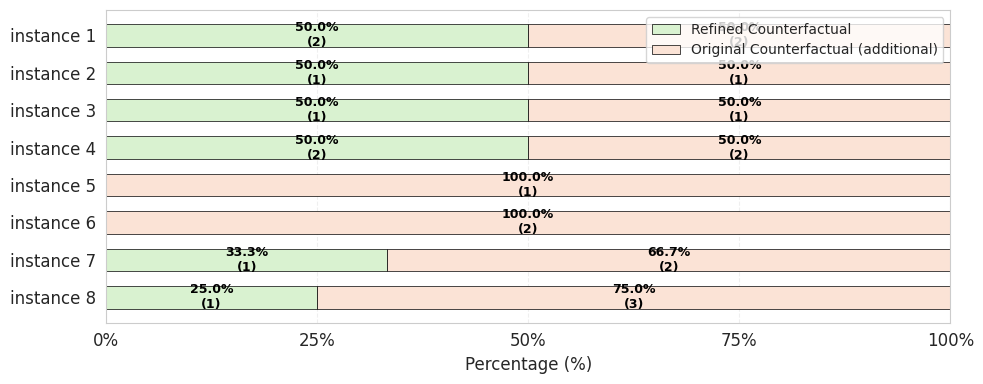

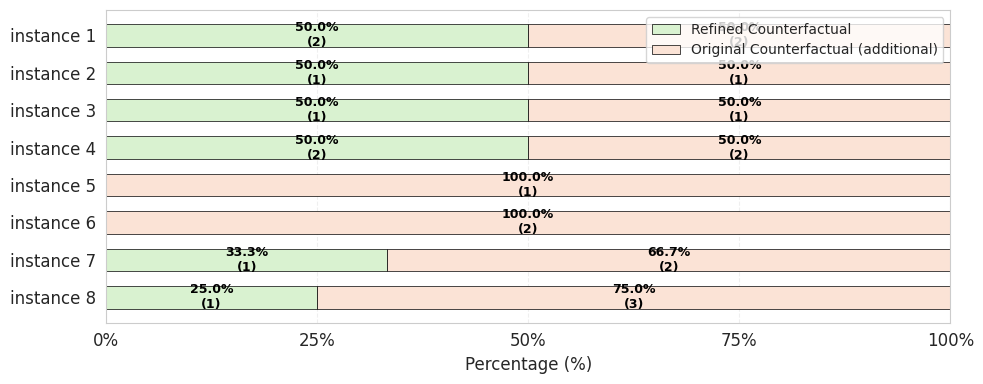

In [46]:
# Столбчатая диаграмма: число действий
sparsifier.stacked_bar_chart(save_path='./results')

Directional changes from factual to counterfactual:
Directional changes from factual to action-limited counterfactual:


(<Figure size 1000x600 with 1 Axes>, <Figure size 1000x600 with 1 Axes>)

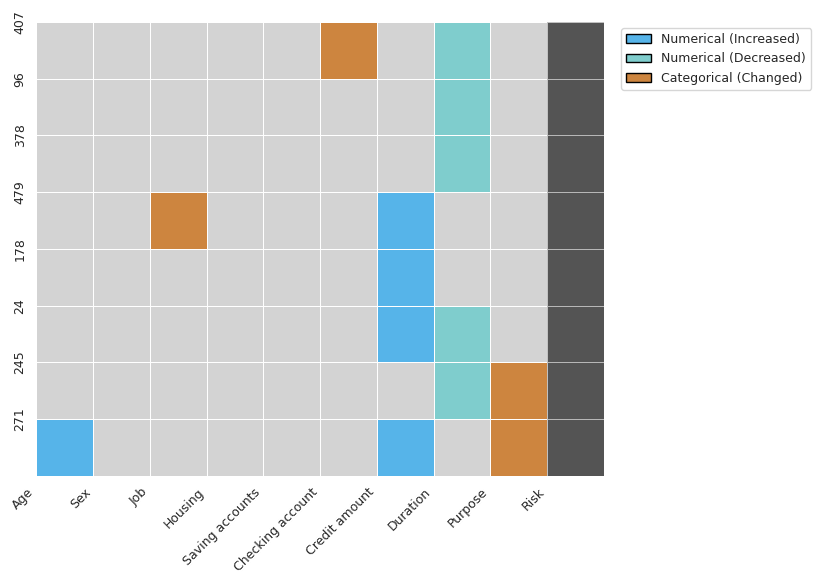

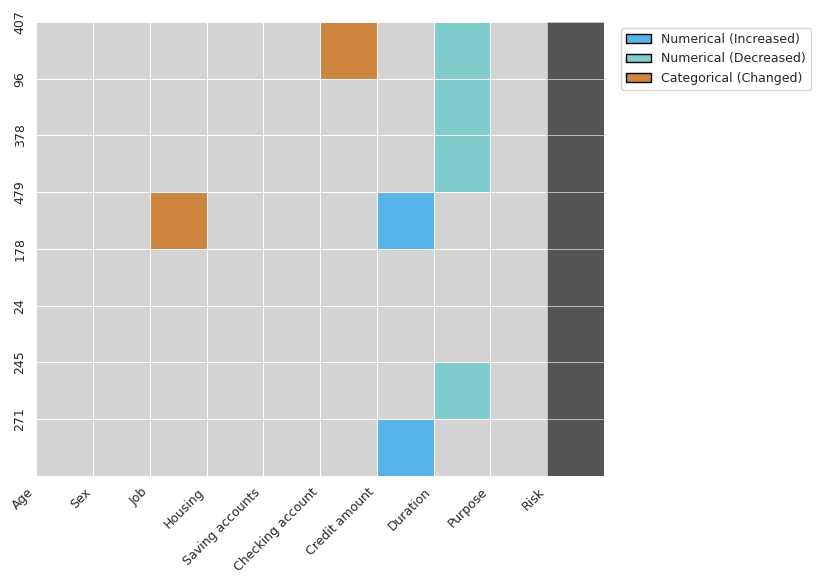

In [47]:
# Тепловая карта направлений изменений
sparsifier.heatmap_direction(
    save_path=None,
    save_mode='combined',
    show_axis_labels=True
)

В общем и целом, COLA имеет красивую теоретическую идею. При желании можно сравнить атрибуции в COLA с shap, или сделать наивную версию COLA, используя shap. Сама библиотека не всегда отрабатывает хорошо, но это прекрасно, что есть и появляются новые реализации разных методов!

Удачных вам контрфактуалов, 

Ваш Дата-автор! :)